# **Mini-batch Gradient Descent: Stability vs Efficiency**

This experiment explores how batch size influences optimization behavior.

We analyze:
- Convergence smoothness
- Noise in updates
- Speed of convergence

Mini-batch gradient descent provides a continuum between:
- SGD (batch_size = 1)
- Batch GD (batch_size = full dataset)

In [6]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from src.model import LogisticRegression
from src.optimizers.minibatch_gd import MiniBatchGradientDescent

from src.utils.data import generate_dataset, standardize
from src.utils.seed import set_seed

In [8]:
set_seed(42)

X, y = generate_dataset()
X = standardize(X)

## **Experimental Setup**

We vary batch size while keeping:
- Learning rate fixed
- Initialization identical
- Dataset constant

Batch sizes evaluated:

[1, 16, 32, 64, N]

Where:
- 1 -> SGD
- N -> Batch Gradient Descent

In [9]:
batch_sizes = [1, 16, 32, 64, X.shape[0]]
results = {}

for bs in batch_sizes:
    set_seed(42)

    model = LogisticRegression(n_features=X.shape[1])
    optimizer = MiniBatchGradientDescent(
        lr=0.01,
        epochs=20,
        batch_size=bs
    )

    loss = optimizer.train(model, X, y)
    results[bs] = loss

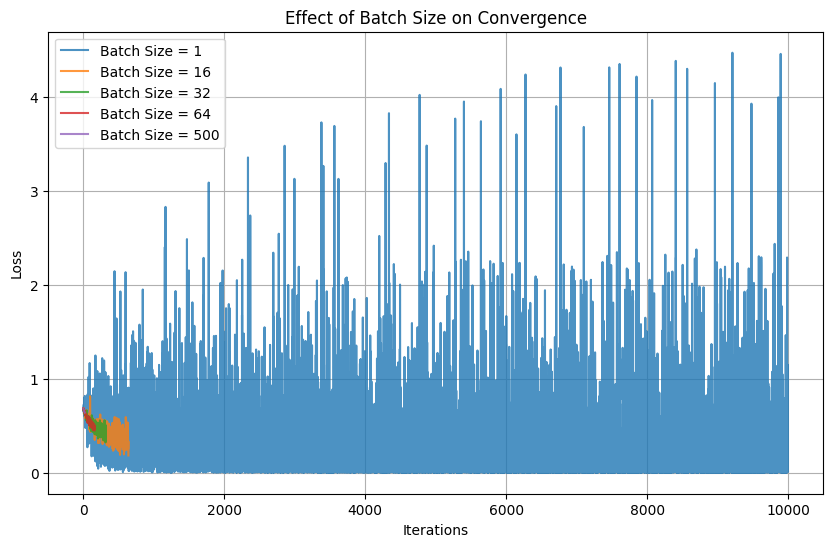

In [10]:
plt.figure(figsize=(10, 6))

for bs, loss in results.items():
    plt.plot(loss, label=f"Batch Size = {bs}", alpha=0.8)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Effect of Batch Size on Convergence")
plt.legend()
plt.grid()

from src.utils.io import ensure_dir

ensure_dir("../experiments")

plt.savefig(
    "../experiments/minibatch_batchsize_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observations**

- **Batch Size = 1 (SGD)**
  - Highly noisy trajectory
  - Fast but unstable updates

- **Small Mini-batches (16, 32)**
  - Reduced noise
  - Faster convergence in practice

- **Larger Mini-batches (64, full)**
  - Smoother curves
  - Slower parameter updates

## Key Insight

Mini-batch gradient descent balances:

- Computational efficiency
- Convergence stability

This is why it is the standard in modern deep learning systems.